# XGBoost

In this notebook, we explore gradient boosting to improve upon our baseline Random Forest:

1. **XGBoost** - Extreme Gradient Boosting with native NaN handling
2. **Hyperparameter Optimization** - Using RandomizedSearchCV
3. **Class-Weighted Training** - Fixing the training objective to handle class imbalance


## Introduction to Gradient Boosting

While Random Forest builds trees independently in parallel (**bagging**), gradient boosting builds trees sequentially, with each tree correcting the errors of the previous ensemble.

**Key advantages:**
- Often achieves better performance than random forests on structured/tabular data
- Native missing value handling (learns optimal splits for NaN)
- Regularization parameters to prevent overfitting

**Trade-offs:**
- More hyperparameters to tune
- Sequential training (slower than parallel random forest)
- More prone to overfitting if not regularized

### sklearn GradientBoostingClassifier vs. XGBoost

Both implement gradient boosting but differ significantly in their engineering:

| Feature | `sklearn.GradientBoostingClassifier` | `XGBClassifier` |
|---|---|---|
| **Missing values** | Requires imputation | Learned natively — finds the optimal split direction for NaN |
| **Speed** | Pure Python/Cython; single-threaded tree fitting | Highly optimised C++; parallel tree construction via `n_jobs` |
| **Regularization** | `max_depth`, `min_samples_*`, `subsample` | All of those plus L1 (`reg_alpha`) and L2 (`reg_lambda`) on leaf weights |
| **Column subsampling** | Not supported | `colsample_bytree`, `colsample_bylevel`, `colsample_bynode` |
| **Approximate split** | Exact greedy split (slow on large data) | Histogram-based approximation (`tree_method='hist'`) for speed |
| **Early stopping** | Not supported in CV workflows | `early_stopping_rounds` on a validation set |
| **Label encoding** | Accepts string labels directly | Requires numeric labels (we use `LabelEncoder` below) |

In practice, XGBoost is almost always preferred for tabular problems: it is faster, handles missing values without preprocessing, and provides stronger regularization controls.


## Data Loading

In [ ]:
from src.data_loader import load_thyroid_data_3_classes
from src.metrics import thyroid_scorer
from src.preprocessing import get_native_nan_pipeline

X_train, X_test, y_train, y_test = load_thyroid_data_3_classes(test_size=0.2, random_state=42)

## XGBoost

XGBoost handles missing values natively by learning the optimal direction to route samples with missing features at each split. This makes imputation unnecessary for XGBoost.

In [ ]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder

# XGBoost requires numeric labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)

print(f"Label mapping: {dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))}")

Label mapping: {'hyperthyroid': 0, 'hypothyroid': 1, 'negative': 2}


In [ ]:
preprocessor = get_native_nan_pipeline()

pipeline_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        n_jobs=-1,
        eval_metric='mlogloss'
    ))
])

In [ ]:
stratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores_xgb = cross_val_score(
    pipeline_xgb, X_train, y_train_encoded,
    cv=stratified_cv,
    scoring=thyroid_scorer
)

print(f"XGBoost - Thyroid Disease F2 Score")
print(f"  Per-fold scores: {scores_xgb.round(3)}")
print(f"  Mean: {scores_xgb.mean():.3f} (+/- {scores_xgb.std() * 2:.3f})")

XGBoost - Thyroid Disease F2 Score
  Per-fold scores: [0.871 0.834 0.911 0.857 0.88 ]
  Mean: 0.870 (+/- 0.051)


## Hyperparameter Tuning with XGBoost

We use RandomizedSearchCV to explore the hyperparameter space efficiently. Key parameters:

- **n_estimators**: Number of boosting rounds
- **max_depth**: Maximum tree depth (controls model complexity)
- **learning_rate**: Step size shrinkage (lower = more conservative)
- **subsample**: Fraction of samples used per tree
- **colsample_bytree**: Fraction of features used per tree

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

param_distributions = {
    'classifier__n_estimators': randint(50, 300),
    'classifier__max_depth': randint(3, 10),
    'classifier__learning_rate': uniform(0.01, 0.29),
    'classifier__subsample': uniform(0.6, 0.4),
    'classifier__colsample_bytree': uniform(0.6, 0.4),
}

random_search_xgb = RandomizedSearchCV(
    pipeline_xgb,
    param_distributions,
    n_iter=20,
    cv=stratified_cv,
    scoring=thyroid_scorer,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [ ]:
random_search_xgb.fit(X_train, y_train_encoded)

print(f"Best Thyroid Disease F2 Score: {random_search_xgb.best_score_:.3f}")
print(f"Best parameters:")
for param, value in random_search_xgb.best_params_.items():
    print(f"  {param}: {value}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Thyroid Disease F2 Score: 0.874
Best parameters:
  classifier__colsample_bytree: 0.6624074561769746
  classifier__learning_rate: 0.055238410897498764
  classifier__max_depth: 5
  classifier__n_estimators: 252
  classifier__subsample: 0.9464704583099741


## Model Comparison

In [ ]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['XGBoost', 'XGBoost (tuned)'],
    'F2 Score': [
        scores_xgb.mean(),
        random_search_xgb.best_score_
    ],
    'Std': [
        scores_xgb.std(),
        random_search_xgb.cv_results_['std_test_score'][random_search_xgb.best_index_]
    ]
}).sort_values('F2 Score', ascending=False)

print("Advanced Model Comparison:")
print(results.to_string(index=False))

Advanced Model Comparison:
          Model  F2 Score      Std
XGBoost (tuned)  0.874379 0.020391
        XGBoost  0.870453 0.025417


## Detailed Evaluation

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

best_xgb = random_search_xgb.best_estimator_
y_pred_cv = cross_val_predict(best_xgb, X_train, y_train_encoded, cv=5, n_jobs=-1)

print("Best XGBoost - Cross-Validation Classification Report:")
print(classification_report(
    y_train_encoded, y_pred_cv, 
    target_names=label_encoder.classes_,
    zero_division=0
))

Best XGBoost - Cross-Validation Classification Report:
              precision    recall  f1-score   support

hyperthyroid       0.82      0.75      0.78       193
 hypothyroid       0.95      0.97      0.96       533
    negative       0.99      0.99      0.99      6611

    accuracy                           0.98      7337
   macro avg       0.92      0.90      0.91      7337
weighted avg       0.98      0.98      0.98      7337



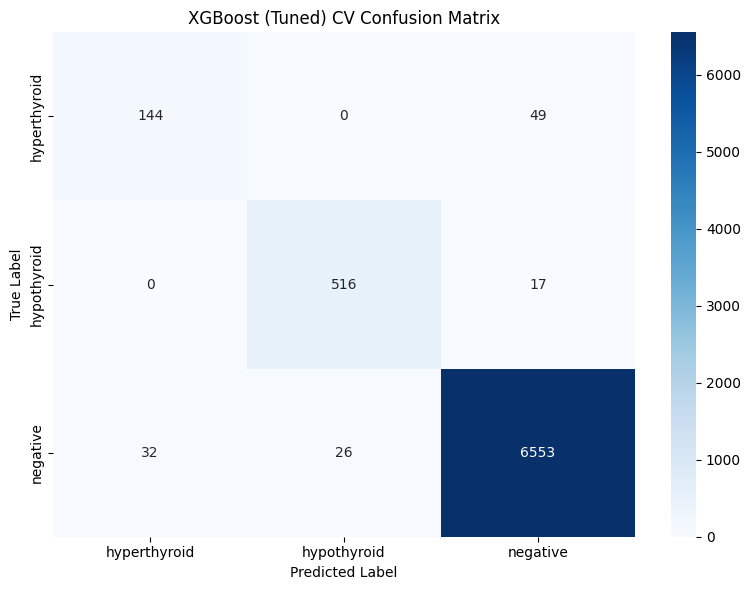

In [ ]:
cm = confusion_matrix(y_train_encoded, y_pred_cv)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('XGBoost (Tuned) CV Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## Why the Scorer Alone Doesn't Improve Recall

The 0.75 recall for hyperthyroid is not acceptable — we are missing 25% of hyperthyroid patients.

The problem is that the F2 scorer only controls **which model wins** in the cross-validation outer loop. It does nothing to the XGBoost *training objective* inside each fold. XGBoost still fits each tree by minimising **unweighted** `mlogloss`, where a misclassified hyperthyroid patient counts exactly the same as a misclassified negative patient — despite the ~33:1 class imbalance.

The fix is to inject **class weights** directly into the training objective, so XGBoost pays more for minority-class errors during tree construction.


## Class-Weighted Training


`sklearn.utils.compute_sample_weight('balanced', y)` computes per-sample weights inversely proportional to class frequency. Passing them as `sample_weight` to XGBoost's `fit()` method makes each sample's contribution to the loss proportional to its weight — directly equivalent to `CrossEntropyLoss(weight=class_weights)` in the neural network (notebook 05).

sklearn handles cross-validation correctly: for each fold only the training-fold subset of `sample_weights` is passed to `fit()`, so there is **no data leakage**.


In [ ]:
from sklearn.utils import compute_sample_weight

# Per-sample weights inversely proportional to class frequency
sample_weights = compute_sample_weight('balanced', y_train_encoded)

pipeline_xgb_weighted = Pipeline([
    ('preprocessor', get_native_nan_pipeline()),
    ('classifier', XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        n_jobs=-1,
        eval_metric='mlogloss'
    ))
])

scores_weighted = cross_val_score(
    pipeline_xgb_weighted, X_train, y_train_encoded,
    cv=stratified_cv,
    scoring=thyroid_scorer,
    params={'classifier__sample_weight': sample_weights}
)
print("Weighted XGBoost - Thyroid Disease F2 Score")
print(f"  Per-fold scores: {scores_weighted.round(3)}")
print(f"  Mean: {scores_weighted.mean():.3f} (+/- {scores_weighted.std() * 2:.3f})")


Weighted XGBoost - Thyroid Disease F2 Score
  Per-fold scores: [0.896 0.861 0.926 0.887 0.914]
  Mean: 0.897 (+/- 0.045)


In [ ]:
random_search_weighted = RandomizedSearchCV(
    pipeline_xgb_weighted,
    param_distributions,
    n_iter=20,
    cv=stratified_cv,
    scoring=thyroid_scorer,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
random_search_weighted.fit(
    X_train, y_train_encoded,
    classifier__sample_weight=sample_weights
)

print(f"Best Thyroid Disease F2 Score: {random_search_weighted.best_score_:.3f}")
print("Best parameters:")
for param, value in random_search_weighted.best_params_.items():
    print(f"  {param}: {value}")


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Thyroid Disease F2 Score: 0.905
Best parameters:
  classifier__colsample_bytree: 0.786705157299192
  classifier__learning_rate: 0.25938271795353296
  classifier__max_depth: 9
  classifier__n_estimators: 70
  classifier__subsample: 0.7801997007878172


In [ ]:
best_xgb_weighted = random_search_weighted.best_estimator_
y_pred_weighted = cross_val_predict(
    best_xgb_weighted, X_train, y_train_encoded, cv=5, n_jobs=-1,
    params={'classifier__sample_weight': sample_weights}
)

print("Weighted XGBoost - Cross-Validation Classification Report:")
print(classification_report(
    y_train_encoded, y_pred_weighted,
    target_names=label_encoder.classes_,
    zero_division=0
))

Weighted XGBoost - Cross-Validation Classification Report:
              precision    recall  f1-score   support

hyperthyroid       0.76      0.86      0.81       193
 hypothyroid       0.94      0.98      0.96       533
    negative       0.99      0.99      0.99      6611

    accuracy                           0.98      7337
   macro avg       0.90      0.94      0.92      7337
weighted avg       0.98      0.98      0.98      7337



## Final Comparison

We now compare the two XGBoost variants (unweighted vs. class-weighted) on disease-class recall and precision.


In [ ]:
import pandas as pd
from sklearn.metrics import classification_report as cr_fn

cr_unweighted = cr_fn(y_train_encoded, y_pred_cv, target_names=label_encoder.classes_, zero_division=0, output_dict=True)
cr_weighted = cr_fn(y_train_encoded, y_pred_weighted, target_names=label_encoder.classes_, zero_division=0, output_dict=True)

rows = []
for label in ['hyperthyroid', 'hypothyroid']:
    for variant, cr in [
        ('Tuned XGBoost (unweighted)', cr_unweighted),
        ('Weighted XGBoost', cr_weighted),
    ]:
        rows.append({
            'Class': label,
            'Variant': variant,
            'Precision': f"{cr[label]['precision']:.3f}",
            'Recall': f"{cr[label]['recall']:.3f}",
            'F1': f"{cr[label]['f1-score']:.3f}",
            'Support': int(cr[label]['support']),
        })

comparison_df = pd.DataFrame(rows).set_index(['Class', 'Variant'])
display(comparison_df)


Precision Recall     F1  Support
Class        Variant                                                    
hyperthyroid Tuned XGBoost (unweighted)     0.818  0.746  0.780      193
             Weighted XGBoost               0.761  0.860  0.808      193
hypothyroid  Tuned XGBoost (unweighted)     0.952  0.968  0.960      533
             Weighted XGBoost               0.936  0.983  0.959      533

## Conclusions

**Key findings:**

- Gradient boosting (XGBoost) achieves a strong baseline; hyperparameter tuning provides marginal additional gains
- **Changing the evaluation scorer alone does not improve recall** — the scorer selects hyperparameters but does not change the training objective; XGBoost still minimises unweighted `mlogloss`
- **Class-weighted training (`sample_weight`)** is the correct fix: it directly changes the loss landscape so XGBoost pays more for minority-class errors during tree construction — equivalent to `CrossEntropyLoss(weight=...)` in the neural network (notebook 05)
- The improvement in disease recall comes at the cost of some precision (more false positives); which trade-off is acceptable depends on clinical context — in this domain a downstream physician review is assumed for all positive predictions
